# Small-Sample Goodness-of-Fit Trial

This notebook runs a tiny goodness-of-fit smoke test for the unit-ball experiment. The sample sizes below are intentionally tiny, so the estimates are only useful for checking that calibration, null evaluation, and alternative-power reporting run end to end

In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
SRC = PROJECT_ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

PROJECT_ROOT

PosixPath('/Users/shunansheng/Documents/Projects/ot_experiment')

In [2]:
import pandas as pd

from otexp.experiment import run_gof_experiment

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

## Parameters

`B` calibrates the critical value under the null. `n_eval` is the number of fresh evaluation replicates for the null and for each alternative specification.

In [3]:
params = dict(
    d=2,
    n=4,
    B=3,
    n_eval=2,
    alpha=0.05,
    n_source=32,
    seed=2026,
    max_iter=10,
    chunk_size=32,
    location_thetas=(0.5,),
    scale_thetas=(0.5,),
    mixture_thetas=(0.5,),
    mixture_shift=0.5,
)

params

{'d': 2,
 'n': 4,
 'B': 3,
 'n_eval': 2,
 'alpha': 0.05,
 'n_source': 32,
 'seed': 2026,
 'max_iter': 10,
 'chunk_size': 32,
 'location_thetas': (0.5,),
 'scale_thetas': (0.5,),
 'mixture_thetas': (0.5,),
 'mixture_shift': 0.5}

In [4]:
summary_df, calibration_null_df, sim_df = run_gof_experiment(**params)

## Rejection Probabilities

The `estimate` column is the empirical rejection probability of `H0`. Under `scenario == "null"`, this is empirical size. Under the alternatives, this is empirical power.

In [5]:
display_cols = [
    "quantity",
    "scenario",
    "alternative",
    "theta",
    "estimate",
    "mc_se",
    "n_eval",
    "alpha",
    "critical_value",
    "success_rate",
    "error_rate",
]

summary_df[display_cols]

,quantity,scenario,alternative,theta,estimate,mc_se,n_eval,alpha,critical_value,success_rate,error_rate
0,empirical size,null,null,0.0,0.5,0.353553,2,0.05,0.379836,1.0,0.0
1,empirical power,location_shift,Y = X + theta e1,0.5,1.0,0.000000,2,0.05,0.379836,1.0,0.0
2,empirical power,scale,Y = (1 + theta) X,0.5,1.0,0.000000,2,0.05,0.379836,1.0,0.0
3,empirical power,mixture_contamination,(1 - theta) mu0 + theta Law(X + 0.5 e1),0.5,0.5,0.353553,2,0.05,0.379836,1.0,0.0


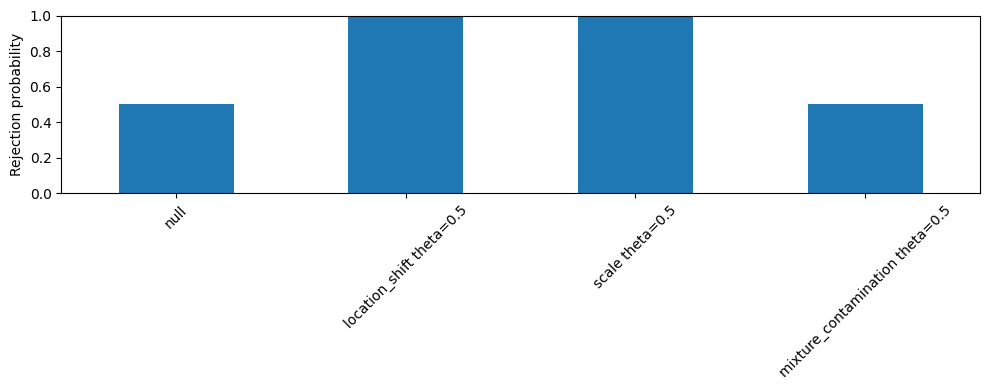

In [6]:
plot_df = summary_df.copy()
plot_df["label"] = plot_df.apply(
    lambda row: "null" if row["scenario"] == "null" else f"{row['scenario']} theta={row['theta']}",
    axis=1,
)

ax = plot_df.plot.bar(x="label", y="estimate", legend=False, figsize=(10, 4), ylim=(0, 1))
ax.set_ylabel("Rejection probability")
ax.set_xlabel("")
ax.tick_params(axis="x", rotation=45)
ax.figure.tight_layout()

## Calibration and Simulation Details

In [7]:
calibration_null_df.head()

,scenario,replicate,seed,T,centered_l1,success,status,message,nit,fun,grad_inf,runtime_seconds,error_message
0,calibration_null,0,2027,0.297945,0.148972,True,0,CONVERGENCE: NORM OF PROJECTED GRADIENT <= PGTOL,7,0.074827,0.0,0.017771,
1,calibration_null,1,2028,0.308072,0.154036,True,0,CONVERGENCE: NORM OF PROJECTED GRADIENT <= PGTOL,4,0.065429,0.0,0.002331,
2,calibration_null,2,2029,0.379836,0.189918,True,0,CONVERGENCE: NORM OF PROJECTED GRADIENT <= PGTOL,6,0.061135,0.0,0.003200,


In [8]:
sim_df.head(12)

,scenario,alternative,theta,replicate,seed,reject,T,centered_l1,success,status,message,nit,fun,grad_inf,critical_value,runtime_seconds,error_message
0,null,null,0.0,0,302026,True,0.437649,0.218825,True,0,CONVERGENCE: NORM OF PROJECTED GRADIENT <= PGTOL,9,-0.019382,0.0,0.379836,0.004694,
1,location_shift,Y = X + theta e1,0.5,0,402026,True,0.735599,0.367799,True,0,CONVERGENCE: NORM OF PROJECTED GRADIENT <= PGTOL,3,-0.213511,0.0,0.379836,0.001376,
2,scale,Y = (1 + theta) X,0.5,0,402027,True,0.393111,0.196556,True,0,CONVERGENCE: NORM OF PROJECTED GRADIENT <= PGTOL,4,0.007098,0.0,0.379836,0.001481,
3,mixture_contamination,(1 - theta) mu0 + theta Law(X + 0.5 e1),0.5,0,402028,True,0.414645,0.207322,True,0,CONVERGENCE: NORM OF PROJECTED GRADIENT <= PGTOL,7,0.045672,0.0,0.379836,0.002725,
4,null,null,0.0,1,302027,False,0.138190,0.069095,True,0,CONVERGENCE: NORM OF PROJECTED GRADIENT <= PGTOL,4,0.139256,0.0,0.379836,0.002603,
5,location_shift,Y = X + theta e1,0.5,1,402029,True,0.821047,0.410523,True,0,CONVERGENCE: NORM OF PROJECTED GRADIENT <= PGTOL,5,-0.329000,0.0,0.379836,0.003294,
6,scale,Y = (1 + theta) X,0.5,1,402030,True,0.810305,0.405153,True,0,CONVERGENCE: NORM OF PROJECTED GRADIENT <= PGTOL,3,-0.236962,0.0,0.379836,0.001567,
7,mixture_contamination,(1 - theta) mu0 + theta Law(X + 0.5 e1),0.5,1,402031,False,0.303553,0.151776,True,0,CONVERGENCE: NORM OF PROJECTED GRADIENT <= PGTOL,6,0.061628,0.0,0.379836,0.002239,
